# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

<div style="background-color:#f1be3e">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           X          |
|------------|----------------------|
| Student A  |        XXXXXXX       |
| Student B  |        XXXXXXX       |
| Student C  |        XXXXXXX       |
| Student D  |        XXXXXXX       |

#### Imports

In [2]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action
np.random.seed(42)
random.seed(42)

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [3]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def execute(self, agent: Agent, maze: Maze, action: Action):
        return agent.step(action,maze), action
    
    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        return self.execute(agent,maze,self.getrandomaction(agent,maze))
    
    def getrandomaction(self, agent: Agent, maze: Maze):
        actions = agent.get_valid_actions(maze)
        action = actions[np.random.randint(len(actions))]
        return action
    
    def e_greedy(self, agent: Agent,  maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps,
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.
        """

        return self.execute(agent,maze,self.getgreedy(agent,maze,eps))

    def getgreedy(self, agent:Agent, maze:Maze, eps: float):
            actions = agent.get_valid_actions(maze)
            if np.random.rand() < eps:
                return self.getrandomaction(agent,maze)
            else:
                scores = [self.q_table.get_q(agent.get_state(maze),a) for a in actions]
                mm0 = np.max(scores)
                candidates = [i for i, v in enumerate(scores) if v == mm0]
                action = actions[random.choice(candidates)]
                return action
            
    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration, and as the temperature declines over time,
        exploitation is favoured. 
        """

        return self.execute(agent, maze, self.getbolt(agent,maze,temperature))
    def getbolt(self, agent: Agent, maze: Maze, temperature: float):
        actions = agent.get_valid_actions(maze)
        scores = np.array([self.q_table.get_q(agent.get_state(maze),a)/ temperature for a in actions])
        scores_stable = scores - np.max(scores)
        output = np.exp(scores_stable) 
        output /= np.sum(output)
        action = np.random.choice(actions, p=output)
        return action

<div style="background-color:#f1be3e">

Random has no hyperparameters nor an interesting implementation, we just pick a random action and take it.

E-greedy calls random with a probablity of the hyperparameter epsilon, for which we choose 0.1 as this seems like it would allow for enough exploration to find a good path while also making sure that our solutions don't get worse on average as we still pick our current best path with 0.9 probability.

Boltzmann takes a path with the probability proportional to its Q-score, similarly to roulette wheel in genetic algorithms. We can tune the temperature to encourage exploration (for high temperatures) or exploitation (low temperatures). We will pick T = 1.5 to encourage exploration in order to help prevent local minima, while still reasonably converging to a good solution.

For sufficient exploration we can use either e-greedy or boltzmann. Random does not have any exploitation and will thus not converge to a good solution, e-greedy/boltzmann with epsilon = 0.1 and temperature = 1.5 respectively have sufficient exploration and exploitation to find paths towards the goal.

#### Question 2

100%|██████████| 300/300 [00:07<00:00, 41.19it/s]


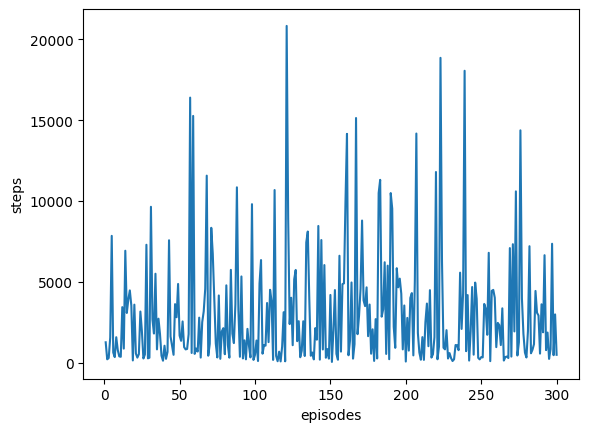

In [4]:
# Create a Maze instance.
maze = Maze("./../data/easy_maze.txt")
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)
n_episodes = 300
def main(maze):
    # Create an Agent.
    agent = Agent(start_x=0, start_y=0)
    # Create a QTable.
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    # Create an ExplorationStrategy.
    exploration_strategy = ExplorationStrategy(q_table)
    # Create a learner.
    params = {"lr": 0.7, "gamma": 0.9}
    # learner = QLearning(q_table, params)


    # Hyper-parameters.

    episode_lengths = []
    episode_rewards = []
    steps = np.zeros(n_episodes)

    for episode in tqdm(range(n_episodes)):
        done = False
        agent.reset()
        while not done:
            state = agent.get_state(maze)
            (next,reward,done),action = exploration_strategy.e_greedy(agent, maze, 0.1)
            valid_actions = agent.get_valid_actions(maze)
            steps[episode] += 1
            #learner.learn(valid_actions,state,action,next,reward,done)
    return steps
steps = main(maze)
plt.xlabel("episodes")
plt.ylabel("steps")
linspace = np.linspace(1,n_episodes, n_episodes)
plt.plot(linspace,steps)

<div style="background-color:#f1be3e">

We get the current state, and the valid actions from that current state, take an e-greedy step (boltzmann would also be possible, both step functions are okay), and we conceptually pass it to the learning method that we will implement later so that we can update the q-table. 

We see that the amount of steps needed to get to the ending is pretty much completely random.

#### Question 3

In [5]:
# Hyper-parameters.

def mainlimited(maze):
    agent = Agent(start_x=0, start_y=0)
    # Create a QTable.
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    # Create an ExplorationStrategy.
    exploration_strategy = ExplorationStrategy(q_table)
    # Create a learner.
    params = {"lr": 0.7, "gamma": 0.9}
    # learner = QLearning(q_table, params)


    # Hyper-parameters.
    n_episodes = 300
    episode_lengths = []
    episode_rewards = []
    steps = np.zeros(n_episodes)
    totalsteps = 0
    episodes = 0
    for episode in tqdm(range(n_episodes)):
        if totalsteps >= 30000:
            break
        done = False
        agent.reset()

        while not done and totalsteps < 30000:
            state = agent.get_state(maze)
            (next,reward,done),action = exploration_strategy.e_greedy(agent, maze, 0.1)
            valid_actions = agent.get_valid_actions(maze)
            steps[episode] += 1
            totalsteps += 1
            if(totalsteps >= 30000):
                steps[episode] = 0
            #learner.learn(valid_actions,state,action,next,reward,done)
        episodes += 1
    return steps, episodes,totalsteps
            
steps2, eps,totalsteps = mainlimited(maze)
print(totalsteps)

  2%|▏         | 6/300 [00:00<00:14, 20.97it/s]

30000


<div style="background-color:#f1be3e">

We count the total steps taken every time we iterate over the loop where a step has been taken. After 30000 steps have been taken, we exit out of both the inner and the outer loop. We print the number of total steps and see that indeed we did 30000 steps. We keep track of the amount of episodes, so we can have an easier time plotting.

#### Question 4

  0%|          | 0/300 [00:00<?, ?it/s]

  3%|▎         | 9/300 [00:00<00:07, 38.16it/s]


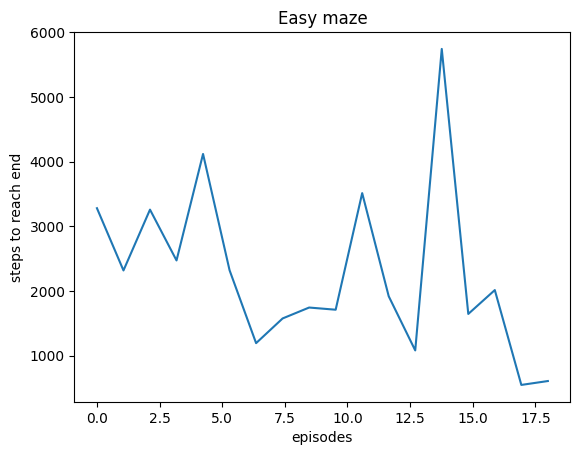

  6%|▌         | 18/300 [00:00<00:03, 78.26it/s]


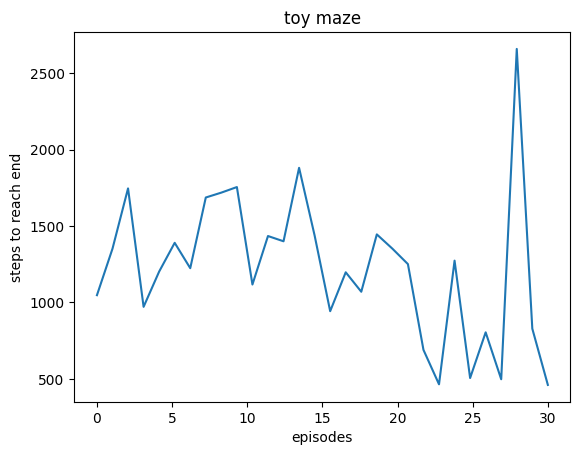

In [6]:

allruns = []
for i in range(10):
    toadd, eps,_ = mainlimited(maze) 
    allruns.append(toadd)
allruns = np.array(allruns)
divisors = np.sum(allruns != 0, axis=0).astype(float)
divisors[divisors==0.0] = 1.0 #prevent dividing by 0
outeasy = np.sum(allruns, axis=0) / divisors
outeasy = outeasy[outeasy != 0.0]
plt.xlabel("episodes")
plt.ylabel("steps to reach end")
plt.title("Easy maze")
plt.plot(np.linspace(0,len(outeasy),len(outeasy)),outeasy)
plt.show()

toymaze = Maze("./../data/toy_maze.txt")
toymaze.set_reward(x=9, y=9, reward=10)
toymaze.set_terminal(x=9, y=9)
allruns = []
for i in range(10):
    toadd, eps,_ = mainlimited(toymaze) 
    allruns.append(toadd)
allruns = np.array(allruns)
divisors = np.sum(allruns != 0, axis=0).astype(float)
divisors[divisors==0.0] = 1.0 #prevent dividing by 0
outeasy = np.sum(allruns, axis=0) / divisors
outeasy = outeasy[outeasy != 0.0]
plt.xlabel("episodes")
plt.ylabel("steps to reach end")
plt.title("toy maze")
plt.plot(np.linspace(0,len(outeasy),len(outeasy)),outeasy)
plt.show()


<div style="background-color:#f1be3e">

For both mazes, what we did is:

Run the algorithm on it 10 times, then take the average over the algorithms that got a non-0 steps solution for it (as this only happens when we exceed 30k steps, making the algorithm not run). For cleanliness we then remove the 0-entries.

As clearly visible, the graphs for both mazes are seemingly completely random. There is no reason to believe there is any correlation.

#### Question 5

In [7]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, possible_actions: List[Action], state: State, action: Action,
               next_state: State, reward: int, done: bool) -> None:
        qmax = 0 if done else np.max(np.array([self.q_table.get_q(next_state,a) for a in possible_actions]))
        current = self.q_table.get_q(state,action)
        value = current + self.params["lr"]*(reward + self.params["gamma"]*qmax - current)
        self.q_table.set_q(state,action,value)

In [8]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
               reward: float, done: bool) -> None:
        qmax = 0 if done else self.q_table.get_q(next_state,next_action)
        current = self.q_table.get_q(state,action)
        value = current + self.params["lr"]*(reward + self.params["gamma"]*qmax - current)
        self.q_table.set_q(state,action,value)

<div style="background-color:#f1be3e">

We implemented Q-learning, who'se formula updates the q-value of the current state and action by checking in which state it maps to and what the best known action is to take in that future state state.

We also implemented SARSA, who is only different becauze it checks what the actual next step taken is instead of the optimal one.

#### Question 6

100%|██████████| 300/300 [00:00<00:00, 871.99it/s]


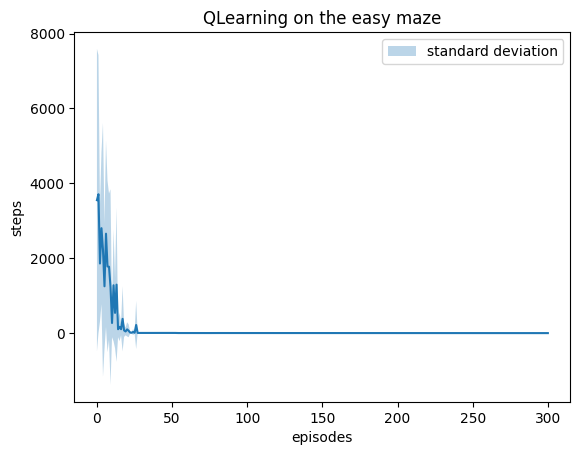

100%|██████████| 300/300 [00:00<00:00, 1240.82it/s]


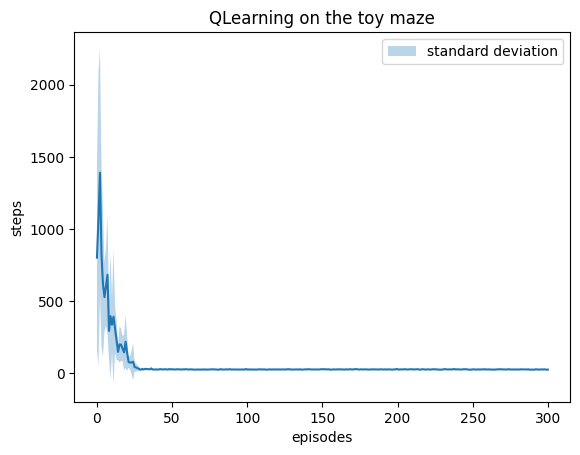

100%|██████████| 300/300 [00:00<00:00, 1286.03it/s]


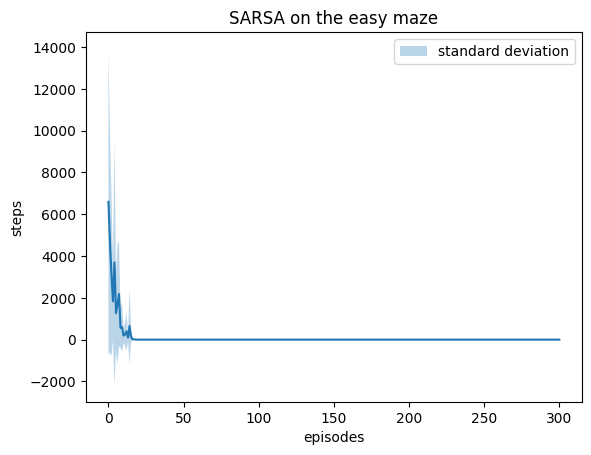

100%|██████████| 300/300 [00:00<00:00, 2567.48it/s]


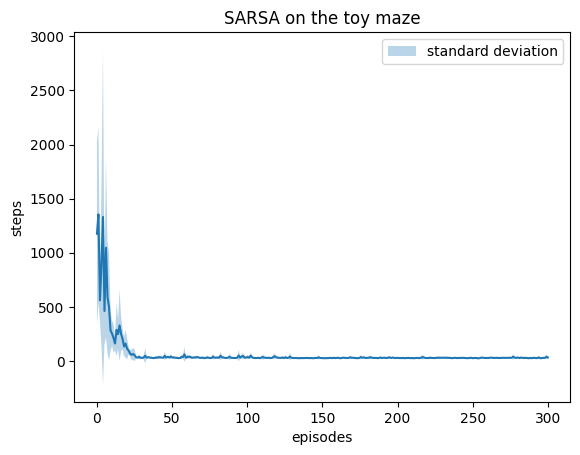

26.0
142.0
24.0
32.0


In [ ]:
def mainwithqlearn(maze):
    agent = Agent(start_x=0, start_y=0)
    # Create a QTable.
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    # Create an ExplorationStrategy.
    exploration_strategy = ExplorationStrategy(q_table)
    # Create a learner.
    params = {"lr": 0.7, "gamma": 0.9}
    learner = QLearning(q_table, params)


    # Hyper-parameters.
    n_episodes = 300
    episode_lengths = []
    episode_rewards = []
    steps = np.zeros(n_episodes)
    totalsteps = 0
    episodes = 0
    for episode in tqdm(range(n_episodes)):
        if totalsteps >= 30000:
            break
        done = False
        agent.reset()

        while not done and totalsteps < 30000:
            state = agent.get_state(maze)
            (next,reward,done),action = exploration_strategy.e_greedy(agent, maze, 0.1)
            valid_actions = agent.get_valid_actions(maze)
            steps[episode] += 1
            totalsteps += 1
            if(totalsteps >= 30000):
                steps[episode] = 0
            learner.learn(valid_actions,state,action,next,reward,done)
        episodes += 1
    return steps, episodes,totalsteps


def mainwithsarsa(maze):
    agent = Agent(start_x=0, start_y=0)
    # Create a QTable.
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    # Create an ExplorationStrategy.
    exploration_strategy = ExplorationStrategy(q_table)
    # Create a learner.
    params = {"lr": 0.7, "gamma": 0.9}
    learner = SARSA(q_table, params)


    # Hyper-parameters.
    n_episodes = 300
    episode_lengths = []
    episode_rewards = []
    steps = np.zeros(n_episodes)
    totalsteps = 0
    episodes = 0
    for episode in tqdm(range(n_episodes)):
       # if totalsteps >= 30000:
        #    break
        done = False
        agent.reset()
        nextaction = exploration_strategy.getgreedy(agent,maze,0.1)
        while not done and totalsteps < 30000:
            state = agent.get_state(maze)
            (next,reward,done),action = exploration_strategy.execute(agent,maze, nextaction)
            nextaction = exploration_strategy.getgreedy(agent,maze,0.1)
            steps[episode] += 1
            totalsteps += 1
            if(totalsteps >= 30000):
                steps[episode] = 0
            learner.learn(state,action,next,nextaction, reward,done)
        episodes += 1
    return steps, episodes,totalsteps
runs = []
for i in range(10):           
    steps_easy_q,_,_ = mainwithqlearn(maze)
    runs.append(steps_easy_q)
runs = np.array(runs)
meanqt, std = np.mean(runs, axis=0), np.std(runs, axis = 0)
plt.xlabel("episodes")
plt.ylabel("steps")
plt.title("QLearning on the easy maze")
plt.plot(np.linspace(0,n_episodes,n_episodes), meanqt)
plt.fill_between(np.linspace(0,n_episodes,n_episodes),meanqt - std, meanqt + std, alpha = 0.3, label = "standard deviation")
plt.legend()
plt.show()

runs = []
for i in range(10):           
    steps_toy_q,_,_ = mainwithqlearn(toymaze)
    runs.append(steps_toy_q)
runs = np.array(runs)
meanqe, std = np.mean(runs, axis=0), np.std(runs, axis = 0)
plt.xlabel("episodes")
plt.ylabel("steps")
plt.title("QLearning on the toy maze")
plt.plot(np.linspace(0,n_episodes,n_episodes), meanqe)
plt.fill_between(np.linspace(0,n_episodes,n_episodes),meanqe - std, meanqe + std, alpha = 0.3, label = "standard deviation")
plt.legend()
plt.show()

runs = []
for i in range(10):           
    steps_easy_sarsa,_,_ = mainwithsarsa(maze)
    runs.append(steps_easy_sarsa)
runs = np.array(runs)
meanse, std = np.mean(runs, axis=0), np.std(runs, axis = 0)
plt.xlabel("episodes")
plt.ylabel("steps")
plt.title("SARSA on the easy maze")
plt.plot(np.linspace(0,n_episodes,n_episodes), meanse)
plt.fill_between(np.linspace(0,n_episodes,n_episodes),meanse - std, meanse + std, alpha = 0.3, label = "standard deviation")
plt.legend()
plt.show()

runs = []
for i in range(10):           
    steps_toy_sarsa,_,_ = mainwithsarsa(toymaze)
    runs.append(steps_toy_sarsa)
runs = np.array(runs)
meanst, std = np.mean(runs, axis=0), np.std(runs, axis = 0)
plt.xlabel("episodes")
plt.ylabel("steps")
plt.title("SARSA on the toy maze")
plt.plot(np.linspace(0,n_episodes,n_episodes), meanst)
plt.fill_between(np.linspace(0,n_episodes,n_episodes),meanst - std, meanst + std, alpha = 0.3, label = "standard deviation")
plt.legend()
plt.show()



<div style="background-color:#f1be3e">

We see the famous elbow shape on all 4 plots, telling us that we converge to a solution on each of them. This also shows that the model is learning, as we clearly see the amount of steps go down with more episodes. It appears that 300 episodes is not fully needed for convergence as both learning algorithms converge before episode 50. Furthermore, we see that the standard deviation is extremely high at the beginning and then evaporates when we converge.

#### Question 7

<div style="background-color:#f1be3e">

The graphs of QLearn are much more smooth than those of SARSA (which has many small "bumps" even after convergence). This is expected as QLearn formula has a lower variance as it always depends on the best move from the future state (its formula contains Q(s′, a_max) which is the q-value of the best action in the next state s′) while SARSA uses the actual next move (its formula contains Q(s′, a′) where a′ is the next action taken in the next state s′ according to our policy) which has a 0.1 chance to be completely random.

### 2.2 Optimization
#### Question 8

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 9

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 10

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 11

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 12

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.3 Introducing More Rewards
#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

## 3. Open Questions
### 3.1 Reflection
#### Question 17

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper
#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**